# **Introdução**

### Descrição do projeto

Você trabalha para a loja online Ice, que vende videogames no mundo todo. As avaliações de usuários e especialistas, gêneros, plataformas e dados históricos sobre vendas de jogos estão disponíveis em fontes abertas. 

Os dados disponibilizados remontam a 2016. Vamos imaginar que estamos em dezembro de 2016 e você está planejando uma campanha para 2017.

### Descrição dos dados

O dataset compactado `games.csv` possui os seguintes atributos/colunas:

* `Name` (Nome do produto)
* `Platform` (Plataforma, como Xbox ou PlayStation)
* `Year_of_Release` (Ano de lançamento)
* `Genre` (Gênero, como Esporte ou Corrida)
* `NA_sales` (Vendas norte-americanas em milhões de USD)
* `EU_sales` (Vendas na Europa em milhões de USD)
* `JP_sales` (Vendas no Japão em milhões de USD)
* `Other_sales` (Vendas em outros países em milhões de USD)
* `Critic_Score` (Pontuação crítica, máximo de 100)
* `User_Score` (Pontuação dos usuários, máximo de 10)
* `Classificação` (ESRB classificação etária, como Teen ou Mature)

### Objetivo

Identificar padrões que determinam se um jogo tem sucesso ou não. Isso vai permitir que você identifique possíveis sucessos e planeje campanhas publicitárias.

# **Setup e Dados**

## Ambiente

### Importação bibliotecas

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats as st

### Configurações Globais

In [2]:
# reprodutibilidade — seed único
RANDOM_STATE = 42

# exibição de dados
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

### Carregamento de dados

In [3]:
# leitura arquivo CSV
games_raw = pd.read_csv('../data/raw/games.csv')

## Pré Processamento

### Primeiras impressões

In [4]:
games_raw.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.00,Sports,41.36,28.96,3.77,8.45,76.00,8,E
1,Super Mario Bros.,NES,1985.00,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.00,Racing,15.68,12.76,3.79,3.29,82.00,8.3,E
3,Wii Sports Resort,Wii,2009.00,Sports,15.61,10.93,3.28,2.95,80.00,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.00,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [5]:
games_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 1.4 MB


O dataset `games_raw` não possui a nomenclatura de suas colunas dentro do padrão *snake case*.

Seria mais adequado mudanças nos tipos de dados em `Year_of_Release` e `User_Score` para `int`, visando operações temporais e numéricas. 

É perceptível a presença de valores nulos nos atributos: `Name` (2), `Year_of_Release` (269), `Genre` (2), `Critic_Score`(8578), `User_Score` (6701) e `Rating` (6766). 
Cada atributo será tratado individualmente, com estratégia adequada ao seu tipo e volume de ausência.


### Tratamento de valores duplicados

In [6]:
# criação de cópia
games = games_raw.copy()

In [7]:
# descoberta quantidade de registros duplicados
print(f'A quantidade de registros duplicados presentes no dataset Games é: {games.duplicated().sum()}')

A quantidade de registros duplicados presentes no dataset Games é: 0


Não foram detectados registros completamente duplicados no dataset. 

Registros com mesmo `Name` e `Platform` não são considerados duplicatas — um mesmo jogo pode ter sido relançado na mesma plataforma em edições distintas, o que justifica a coexistência de entradas idênticas nesses dois atributos.

### Tratamento de valores nulos 

#### Atributo `Name` e `Genre`

In [8]:
# visulização dataset filtrado por nulos em Name
games[games['Name'].isnull()]

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
659,NaN,GEN,1993.00,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.00,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


In [9]:
# preenchimento com designação neutra
games['Name'] = games['Name'].fillna('unknown')
games['Genre'] = games['Genre'].fillna('unknown')

Os 2 registros sem `Name` e `Genre` (0.012% do dataset) correspondem a entradas da plataforma GEN datadas de 1993, sem qualquer identificação recuperável. 

A remoção desses registros foi descartada por serem portadores de dados válidos de vendas. A designação `unknown` foi adotada como marcação neutra que não interfere em agrupamentos nem introduz viés nas análises.

#### Atributo `Year_of_Release` 

In [10]:
# visulização dataset filtrado por nulos em Year_of_release
games[games['Year_of_Release'].isnull()]

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.00,8.5,E
377,FIFA Soccer 2004,PS2,NaN,Sports,0.59,2.36,0.04,0.51,84.00,6.4,E
456,LEGO Batman: The Videogame,Wii,NaN,Action,1.80,0.97,0.00,0.29,74.00,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,NaN,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16373,PDC World Championship Darts 2008,PSP,NaN,Sports,0.01,0.00,0.00,0.00,43.00,tbd,E10+
16405,Freaky Flyers,GC,NaN,Racing,0.01,0.00,0.00,0.00,69.00,6.5,T
16448,Inversion,PC,NaN,Shooter,0.01,0.00,0.00,0.00,59.00,6.7,M
16458,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [11]:
# criação de função para preenchimento de nulos em Year_of_Release com base na mediana dos registros do mesmo jogo em outras plataformas, ou mediana do genêro em plataforma  
def fixing_year(row):
    name = row['Name']
    year = row['Year_of_Release']
    platform = row['Platform']
    genre = row['Genre']

    # teste valor nulo em atributo ano
    if pd.notna(year):
        return year

    match = games[(games['Name'] == name) & (games['Platform'] != platform)]['Year_of_Release']
    median_year = match.median()
    
    # teste valor nulo após filtro por jogo
    if pd.notna(median_year):
        return median_year

    match = games[(games['Platform'] == platform) & (games['Genre'] == genre)]['Year_of_Release']
    median_year = match.median()

    # teste valor nulo após filtro por plataforma e genêro
    if pd.notna(median_year):
        return median_year

    return year

In [12]:
# aplicação da função para preenchimento de nulo em Year_of_Release
games['Year_of_Release'] = games.apply(fixing_year, axis=1) 

In [13]:
# quantidade de valores nulos em Year_of_Release após uso de função
games['Year_of_Release'].isnull().sum()

np.int64(0)

A função `fixing_year` aplica uma lógica de preenchimento em dois níveis hierárquicos:

1. **Mesmo jogo, outras plataformas:** se o título existe em outra plataforma com ano conhecido, usa-se a mediana desses registros — pressuposto de que um jogo tende a ser lançado em múltiplas plataformas no mesmo período.
2. **Mesma plataforma e gênero:** como fallback, utiliza-se a mediana dos jogos do mesmo gênero na mesma plataforma — aproximação razoável para estimar a janela temporal de lançamentos similares.

Os 269 registros ausentes (~1.6% do dataset) foram todos preenchidos com base em outros registros do mesmo jogo, ou como plano B: com base em registros sobre o genêro e plataforma.  

#### Atributo `Critic_Score`

In [14]:
# visulização dataset filtrado por nulos em Critic_Score
games[games['Critic_Score'].isnull()]

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
1,Super Mario Bros.,NES,1985.00,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996.00,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.00,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984.00,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005.00,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.00,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.00,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.00,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.00,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [15]:
# criação de função para preenchimento de nulos em Critic_Score com base na mediana dos registros do mesmo jogo em outras plataformas, ou com base na mediana do genêro em plataforma  
def fixing_critic(row):
    name = row['Name']
    critic = row['Critic_Score']
    platform = row['Platform']
    genre = row['Genre']

    # teste valor nulo em atributo critic_score
    if pd.notna(critic):
        return critic

    match = games[(games['Name'] == name) & (games['Platform'] != platform)]['Critic_Score']
    median_critic = match.median()
    
    # teste valor nulo após filtro por jogo
    if pd.notna(median_critic):
        return median_critic

    match = games[(games['Platform'] == platform) & (games['Genre'] == genre)]['Critic_Score']
    median_critic = match.median()

    # teste valor nulo após filtro por plataforma e genêro
    if pd.notna(median_critic):
        return median_critic

    return critic

In [16]:
# aplicação da função para preenchimento de nulo em Critic_Score
games['Critic_Score'] = games.apply(fixing_critic, axis=1) 

In [17]:
# quantidade de valores nulos em Critic_Score após uso de função
games['Critic_Score'].isnull().sum()

np.int64(1074)

A função `fixing_critic` segue a mesma hierarquia de `fixing_year`: primeiro busca o mesmo jogo em outras plataformas; na ausência de correspondência, utiliza a mediana dos jogos do mesmo gênero na plataforma. 

O volume inicial de ausentes em `Critic_Score` é expressivo (~51.3% do dataset). Dos 8.578 registros ausentes, 7.504 (~87.5% destes) foram preenchidos por imputação. 

Os 1.074 restantes (~6.4% do dataset) não possuem nem referência por título nem por gênero+plataforma. 

Esses registros são mantidos: removê-los excluiria jogos com dados de vendas válidos e introduziria viés de cobertura — jogos avaliados pela crítica tendem a ser os de maior visibilidade.

#### Atributo `User_Score`

In [18]:
# visulização dataset filtrado por nulos em User_Score
games[games['User_Score'].isnull()]

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
1,Super Mario Bros.,NES,1985.00,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996.00,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.00,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984.00,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005.00,Simulation,9.05,10.95,1.93,2.74,65.50,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.00,Action,0.00,0.00,0.01,0.00,71.00,NaN,NaN
16711,LMA Manager 2007,X360,2006.00,Sports,0.00,0.01,0.00,0.00,73.00,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.00,Adventure,0.00,0.00,0.01,0.00,72.00,NaN,NaN
16713,Spirits & Spells,GBA,2003.00,Platform,0.01,0.00,0.00,0.00,71.00,NaN,NaN


In [19]:
# criação de função para preenchimento de nulos em User_Score com base na mediana dos registros do mesmo jogo em outras plataformas, ou com base na mediana do genêro em plataforma  
def fixing_user(row):
    name = row['Name']
    user = row['User_Score']
    platform = row['Platform']
    genre = row['Genre']

    # teste valor nulo em atributo user_score
    if pd.notna(user):
        return user

    match = games[(games['Name'] == name) & (games['Platform'] != platform)]['User_Score']
    match = pd.to_numeric(match, errors='coerce')
    median_user = match.median()
    
    # teste valor nulo após filtro por jogo
    if pd.notna(median_user):
        return median_user

    match = games[(games['Platform'] == platform) & (games['Genre'] == genre)]['User_Score']
    match = pd.to_numeric(match, errors='coerce')
    median_user = match.median()

    # teste valor nulo após filtro por plataforma e genêro
    if pd.notna(median_user):
        return median_user

    return user

In [20]:
# aplicação da função para preenchimento de nulo em User_Score
games['User_Score'] = games.apply(fixing_user, axis=1) 

In [21]:
# quantidade de valores nulos em User_Score após uso de função
games['User_Score'].isnull().sum()

np.int64(1073)

A função `fixing_user` aplica a mesma hierarquia das anteriores. 

`User_Score` apresenta uma particularidade: o dado original contém entradas `'tbd'` (*to be determined*), convertidas para `NaN` via `pd.to_numeric(errors='coerce')` antes do cálculo da mediana — necessário para evitar que strings contaminem a agregação numérica.

Dos 6.701 ausentes (~40.1% do dataset), 5.628 (~84% destes) foram preenchidos. 

Os 1.073 remanescentes (~6.4% do dataset) são mantidos pelo mesmo critério aplicado a `Critic_Score`: não há base de imputação válida dentro do próprio dataset, e a remoção enviesaria a amostra contra jogos sem avaliação de usuários.

#### Atributo `Rating`

In [22]:
# visulização dataset filtrado por nulos em Rating
games[games['Rating'].isnull()]

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
1,Super Mario Bros.,NES,1985.00,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996.00,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.00,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984.00,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005.00,Simulation,9.05,10.95,1.93,2.74,65.50,7.30,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.00,Action,0.00,0.00,0.01,0.00,71.00,7.20,NaN
16711,LMA Manager 2007,X360,2006.00,Sports,0.00,0.01,0.00,0.00,73.00,6.60,NaN
16712,Haitaka no Psychedelica,PSV,2016.00,Adventure,0.00,0.00,0.01,0.00,72.00,7.60,NaN
16713,Spirits & Spells,GBA,2003.00,Platform,0.01,0.00,0.00,0.00,71.00,8.05,NaN


In [23]:
# criação de função para preenchimento de nulos em Rating com base na mediana dos registros do mesmo jogo em outras plataformas, ou com base na mediana do genêro em plataforma  
def fixing_rating(row):
    name = row['Name']
    rating = row['Rating']
    platform = row['Platform']
    genre = row['Genre']

    # teste valor nulo em atributo user_score
    if pd.notna(rating):
        return rating

    match = games[(games['Name'] == name) & (games['Platform'] != platform)]['Rating']
    mode_rating = match.mode()
    
    # teste valor nulo após filtro por jogo
    if not mode_rating.empty:
        return mode_rating.iloc[0]

    match = games[(games['Platform'] == platform) & (games['Genre'] == genre)]['Rating']
    mode_rating = match.mode()

    # teste valor nulo após filtro por plataforma e genêro
    if not mode_rating.empty:
        return mode_rating.iloc[0]
    
    return rating

In [24]:
# aplicação da função para preenchimento de nulo em Rating
games['Rating'] = games.apply(fixing_rating, axis=1) 

In [25]:
# quantidade de valores nulos em Rating após uso de função
games['Rating'].isnull().sum()

np.int64(1066)

`Rating` é uma variável categórica (classificação ESRB: `EC`, `E`, `E10+`, `T`, `M`, `AO`). Por isso, o preenchimento utiliza **moda** — o valor mais frequente no grupo de referência — em vez de mediana, que seria semanticamente inválida para categorias. A mesma hierarquia é mantida: mesmo jogo em outras plataformas; como fallback, mesma plataforma e gênero.

Dos 6.766 ausentes (~40.5% do dataset), 5.700 (~84.3% destes) foram preenchidos. 

Os 1.066 remanescentes (~6.4% do dataset) são mantidos — `Rating` será usada como variável de segmentação auxiliar, e sua ausência não compromete as análises centrais de vendas.

### Nomenclatura colunas

In [26]:
# nomenclatura de colunas
to_fix_columns = games.columns

In [27]:
# função para adoção do método snake_case em colunas
def rename_columns(columns):
    fixed_columns = list()
    for column in columns:
        column = column.strip().lower().replace(' ', '_')
        fixed_columns.append(column)
    return fixed_columns

In [28]:
# aplicação da função rename_columns
games.columns = rename_columns(to_fix_columns)

A padronização para *snake_case* garante consistência no acesso a colunas por índice string ao longo de todo o notebook, eliminando necessidade de ajustes pontuais por capitalização.

### Alteração tipo de dado

In [29]:
# transformação year_of_release 
games['year_of_release'] = games['year_of_release'].astype(int)

In [30]:
# transformação user_score
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')

A coluna `year_of_release` foi convertida para `int` — o atributo representa o ano calendário. Será suficiente para preservar a compatibilidade com agrupamentos e filtros de intervalo usados nas análises.

A coluna `user_score` foi convertida para de `str` para `float64` após conversão de entradas `'tbd'` (*to be determined*) para `NaN` — strings que bloqueiam operações numéricas. 

### Engenharia de Características

In [31]:
# criação coluna total_sales
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']

`total_sales` agrega as vendas das quatro regiões disponíveis (`na_sales`, `eu_sales`, `jp_sales`, `other_sales`), representando o volume global de vendas de cada registro. 

Essa coluna será a principal métrica de desempenho comercial nas análises seguintes.

In [32]:
# ajuste coluna critic_score
games['critic_score'] = games['critic_score'] / 10

O atributo `critic_score` variava de 0-100, enquanto `user_score` de 0-10. A divisão feita visa manter ambos nivelados, visando maior equiparidade ao visualizar caracteristícas.

# **EDA**

### Distribuição variáveis alvo

In [33]:
# visualização características atributos numéricos
games.describe().T

,count,mean,std,min,25%,50%,75%,max
year_of_release,16715.00,2006.47,5.90,1980.00,2003.00,2007.00,2010.00,2016.00
na_sales,16715.00,0.26,0.81,0.00,0.00,0.08,0.24,41.36
eu_sales,16715.00,0.15,0.50,0.00,0.00,0.02,0.11,28.96
jp_sales,16715.00,0.08,0.31,0.00,0.00,0.00,0.04,10.22
other_sales,16715.00,0.05,0.19,0.00,0.00,0.01,0.03,10.57
critic_score,15641.00,6.87,1.14,1.30,6.30,6.95,7.50,9.80
user_score,13218.00,7.30,1.23,0.00,6.90,7.60,8.10,9.70
total_sales,16715.00,0.53,1.55,0.00,0.06,0.17,0.47,82.54


#### Year of Release

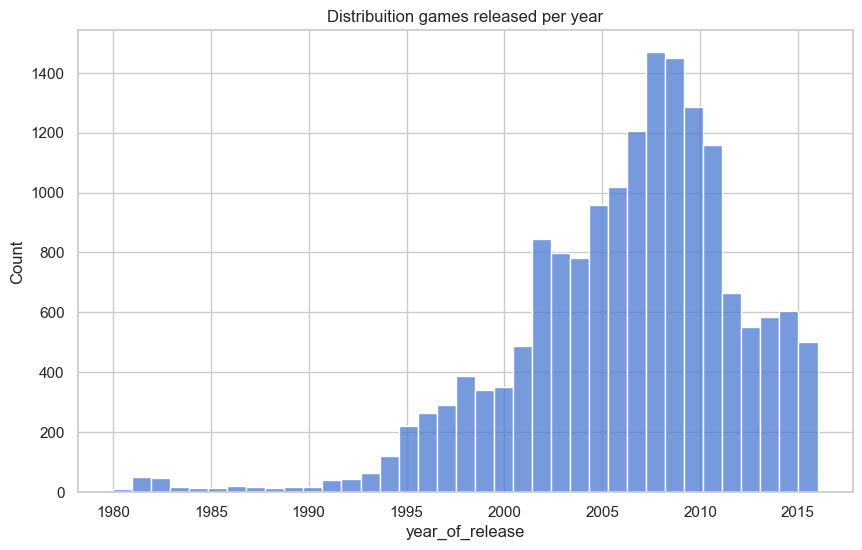

In [34]:
# criação diagrama de histogramo para visualização atributo alvo
plt.title('Distribuition games released per year')
sns.histplot(games['year_of_release'], bins=games['year_of_release'].nunique())
plt.show()

A distribuição do atributo `year_of_release` é assimétrica à esquerda.

As ocorrências de valores estão entre os anos de 1980 e 2016. 

Sua mediana está em 2007. 
Os 25% iniciais da distribuição (Q1) estão entre 1980 e 2003 (23 anos) enquanto os 25% da cauda (Q4) estão entre os anos de 2010 e 2016 (6 anos).  

Isso significa que 50% dos lançamentos foram feitos entre 2003 e 2010 (7 anos).

#### Total Sales

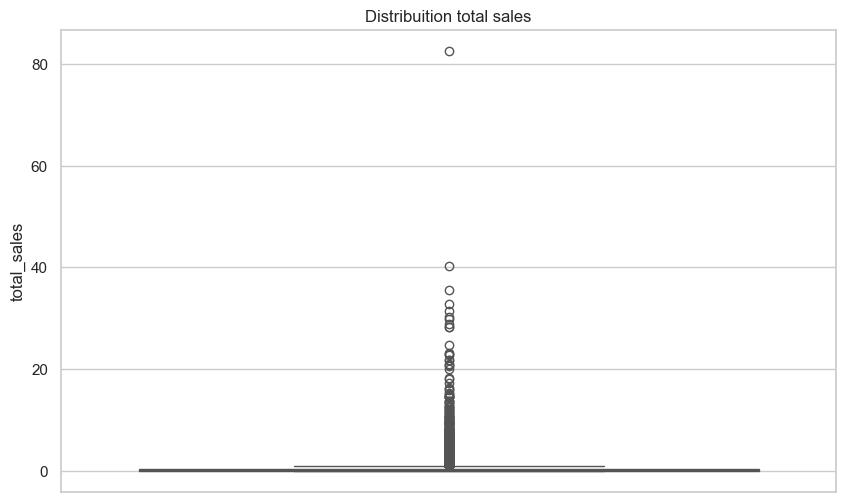

In [35]:
# criação diagrama de caixa para visualização variável alvo
plt.title('Distribuition total sales')
sns.boxplot(games['total_sales'])
plt.show()

A distribuição de `total_sales` é extremamente assimétrico à direita. As ocorrências de valores estão entre 0 e 82,54 (em milhões de USD). 

Sua mediana está em 0.17 (milhões de USD). 
O Q1 da distribuição está entre 0 e 0.06 (milhões de USD). 
O Q4 da distribuição está entre 0.17 e 0.47 (milhões de USD).  

A ilustração demonstra que poucos títulos detém a maior parte das receitas.

#### Sales per Region

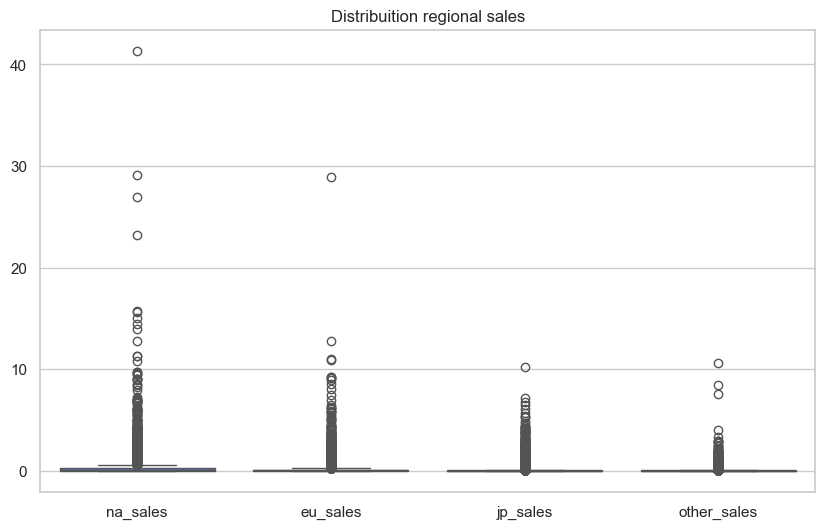

In [36]:
# criação diagrama de caixa para visualização variável alvo
plt.title('Distribuition regional sales')
sns.boxplot(games[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']])
plt.show()

A distribuição dos atributos de vendas regionais (`na_sales`, `eu_sales`, `jp_sales`, `other_sales`) segue padrão similar visto em `total_sales`: distribuição extremamente assimétrica à direita, demonstrando que poucos títulos detém a maior parte das receitas.

#### Critic e User Scores

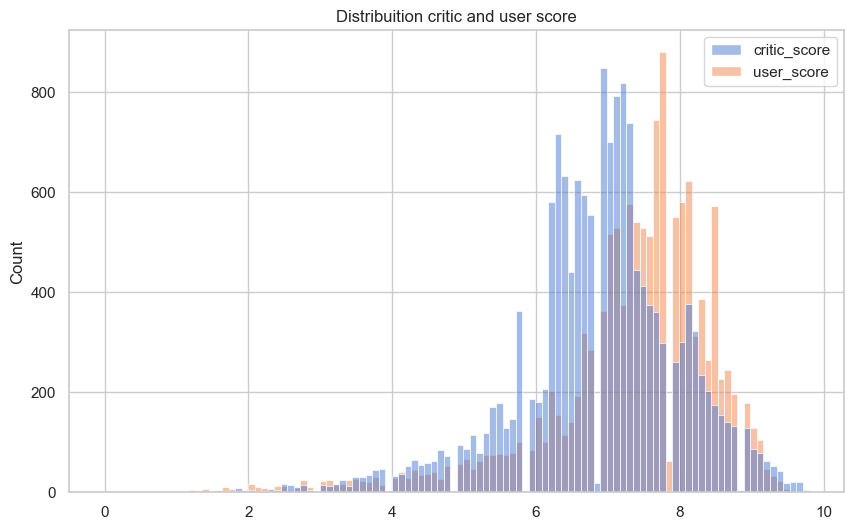

In [37]:
# criação histograma para visualização variável alvo
plt.title('Distribuition critic and user score')
sns.histplot(games[['critic_score', 'user_score']])
plt.show()

A distribuição de `critic_score` e `user_score` apresenta semelhanças: distribuição assimétrica à esquerda, respectivamente medianas de 6.95 x 7.6.

### Investigação Plataformas

#### Plataformas com maior receita

In [38]:
# criação agregado de plataformas baseado em total de vendas
sales_per_platforms = games.groupby('platform').agg({
    'total_sales' : 'sum'
    }).reset_index().sort_values('total_sales', ascending=True)

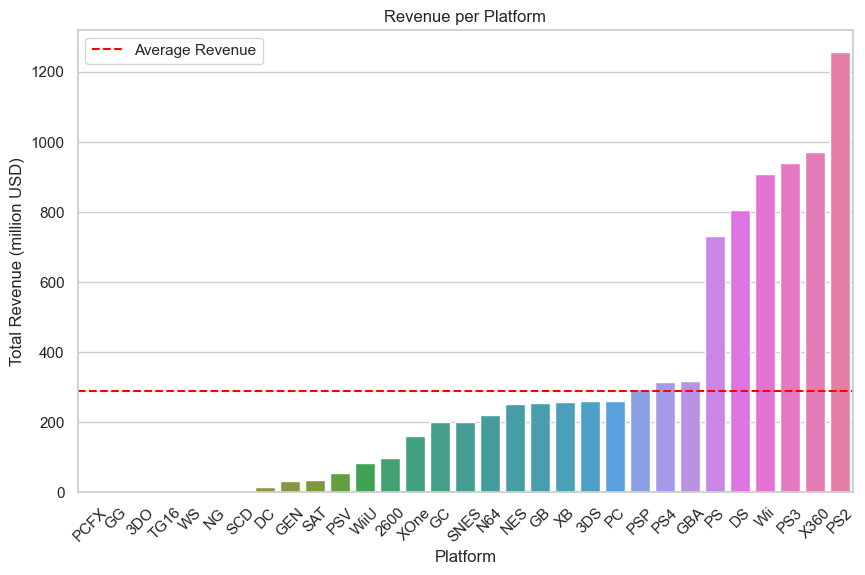

In [39]:
# criação gráfico de barras para visualização resultados agregado
sns.barplot(data=sales_per_platforms, x='platform', y='total_sales', hue='platform')
plt.title('Revenue per Platform')
plt.ylabel('Total Revenue (million USD)')
plt.xlabel('Platform')
plt.axhline(
    y=sales_per_platforms['total_sales'].mean(),
    linestyle='--', 
    color='red',
    label='Average Revenue')
plt.legend()
plt.xticks(rotation=45)
plt.show()

As plataformas com maiores valores de receita durante o período observado são PS2, X360, PS3, Wii, DS e PS.

#### Gêneros com maior receita

In [40]:
# criação agregado de gênero baseado em total de vendas
sales_per_genre = games.groupby('genre').agg({
    'total_sales' : 'sum'
    }).reset_index().sort_values('total_sales', ascending=True)
sales_per_genre = sales_per_genre[sales_per_genre['genre'] != 'unknown']

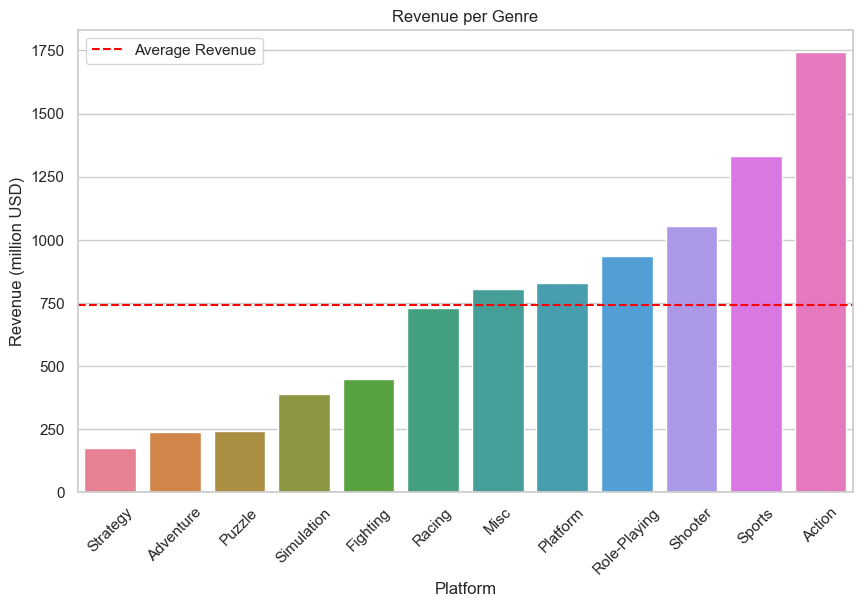

In [41]:
# criação gráfico de barras para visualização resultados agregado
sns.barplot(data=sales_per_genre.dropna(), x='genre', y='total_sales', hue='genre')
plt.title('Revenue per Genre')
plt.ylabel('Revenue (million USD)')
plt.xlabel('Platform')
plt.xticks(rotation=45)
plt.axhline(y=sales_per_genre['total_sales'].mean(),
            linestyle='--',
            color='red',
            label='Average Revenue'
            )
plt.legend()
plt.show()

Os genêros com maiores valores de receita durante o período observado são Action, Sports, Shooter, Role-Playing e Platform.

#### Tempo de vida de plataformas

In [42]:
# criação de agregado de plataformas baseados no ano de seus primeiros e último lançamentos desconsiderando as imputações artificiais
lifetime = games_raw.dropna(subset='Year_of_Release').groupby('Platform').agg(
    last_launch=('Year_of_Release', 'max'),
    first_launch=('Year_of_Release', 'min')
).reset_index()

In [43]:
# criação coluna diferença de idade
lifetime['lifetime'] = lifetime['last_launch'] - lifetime['first_launch']
print(f'Total de plataformas: {len(lifetime)}')
lifetime.sort_values('last_launch', ascending=False)

Total de plataformas: 31


,Platform,last_launch,first_launch,lifetime
2,3DS,2016.00,2011.00,5.00
13,PC,2016.00,1985.00,31.00
27,WiiU,2016.00,2012.00,4.00
26,Wii,2016.00,2006.00,10.00
20,PSV,2016.00,2011.00,5.00
17,PS3,2016.00,2006.00,10.00
18,PS4,2016.00,2013.00,3.00
28,X360,2016.00,2005.00,11.00
30,XOne,2016.00,2013.00,3.00
19,PSP,2015.00,2004.00,11.00


O ciclo de vida médio das plataformas no dataset, medido entre o primeiro e o último lançamento registado, situa-se entre 3 e 11 anos para consoles domésticos e portáteis da geração recente.

Das 31 plataformas presentes no dataset, apenas 9 seguem recebendo lançamentos, que representa ~29% do total. 

Plataformas como PS2, X360, PS3 e Wii apresentam janelas de 10–11 anos — padrão consistente com o histórico da indústria de aproximadamente uma geração por década. 

PS4 e Xbox One, com apenas 4 anos de dados disponíveis (2013–2016), e WiiU 4 anos (2012-2016) são plataformas relativamente recentes — o que reforça sua relevância como plataformas-alvo para 2017.

>DECISÃO METODOLÓGICA

Dois filtros serão aplicados em sequência:

1. **Plataformas ativas:** serão consideradas apenas as plataformas com lançamentos registados nos últimos 3 anos (2014–2016), eliminando plataformas descontinuadas.

2. **Janela de títulos:** dentro dessas plataformas, serão mantidos títulos lançados entre 2012 e 2016, capturando os últimos 5 anos de tendência de mercado.

In [44]:
# seleção plataformas que ainda recebem jogos
recent_platforms = lifetime[lifetime['last_launch'] >= 2014.00]['Platform'].unique()

In [45]:
# aplicação filtro dataset
games_active = games[(games['platform'].isin(recent_platforms)) & (games['year_of_release'] >= 2012)].copy()

### Correlações

In [46]:
# filtro atributos numéricas
numeric_cols = games_active.select_dtypes(include='number').drop(columns='year_of_release')

In [47]:
# cálculo de correlação entre variáveis
corr_matrix = numeric_cols.corr()

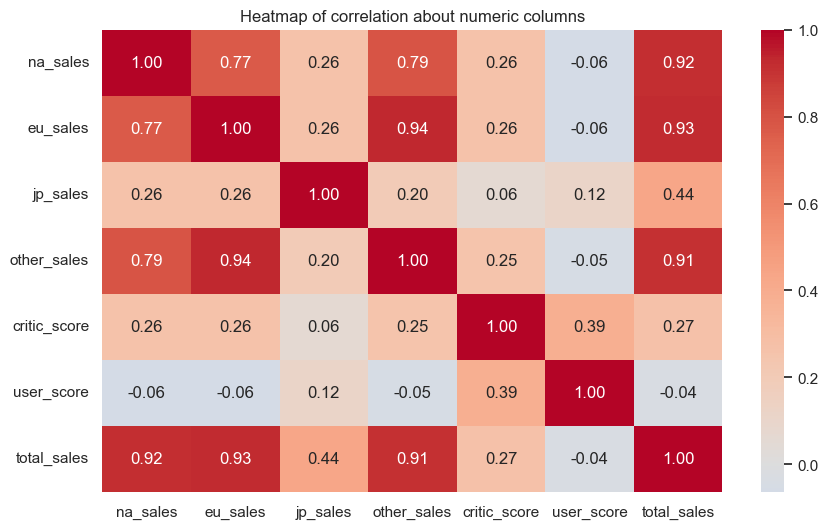

In [48]:
# criação mapa de calor com base em correlações
plt.title('Heatmap of correlation about numeric columns')
sns.heatmap(
    data=corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
    )
plt.show()

É constatada correlação levemente positiva entre `critic_score` e `total_sales` (0.27), o que pode significar que jogos com notas mais altas da crítica tendem a apresentar vendas um pouco maiores.

A correlação entre `user_score` e `total_sales` é praticamente nula (-0.04), o que pode significar que jogos com notas mais altas dos usuários não tendem a vender mais. 

Contudo, é notável a correlação positiva moderada entre `critic_score` e `user_score` (0.38), o que pode significar que títulos com notas mais altas dos críticos jogadores também tendem a receber notas mais altas dos jogadores.  

### Perfil regional 

Visando maior assertividade, deve-se considerar as características culturais e regionais para recomendações personalizadas.

#### North America

##### Platform

In [49]:
# agregado vendas brutas por plataforma em NA
sales_per_platforms_na = games_active.groupby('platform')['na_sales'].sum().reset_index().sort_values('na_sales', ascending=True)

In [50]:
# agregado vendas brutas por plataforma em NA ao longo dos últimos anos
platforms_performance_na = games_active.groupby(['platform', 'year_of_release'])['na_sales'].sum().reset_index()

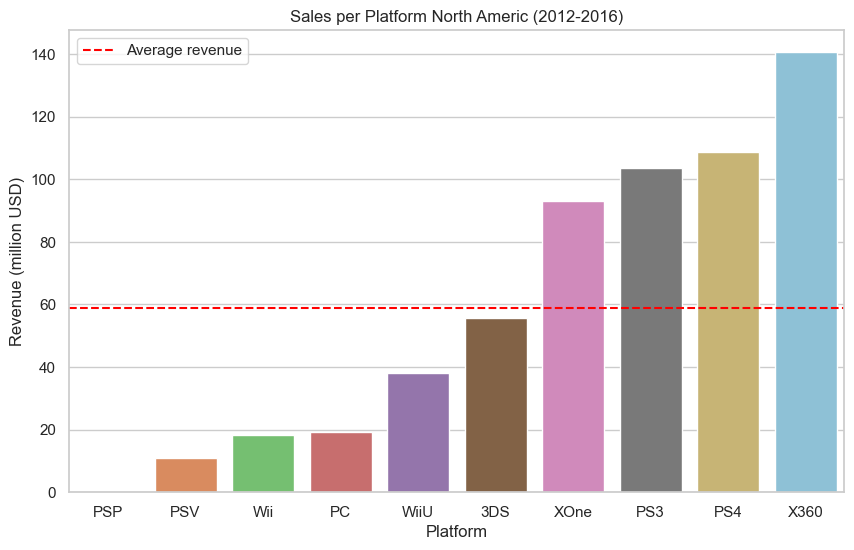

In [83]:
# criação gráfico de barras para visualização resultados agregado
sns.barplot(
    data=sales_per_platforms_na, 
    x='platform', 
    y='na_sales', 
    hue='platform'
    )
plt.title('Sales per Platform North Americ (2012-2016)')
plt.ylabel('Revenue (million USD)')
plt.xlabel('Platform')
plt.axhline(
    y=sales_per_platforms_na['na_sales'].mean(),
    linestyle='--',
    color='red',
    label='Average revenue'
    )
plt.legend()
plt.show()

Em números brutos, as plataformas com maior receita na América do Norte são X360, PS4, PS3 e XOne.

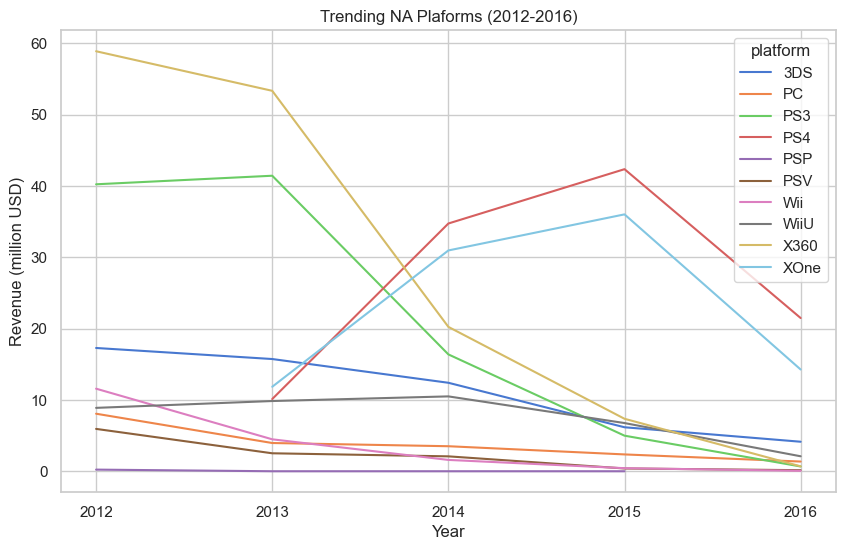

In [52]:
# visualização tendência de vendas em plataformas últimos 5 anos
sns.lineplot(
    data=platforms_performance_na,
    x='year_of_release',
    y='na_sales',
    hue='platform'
)
plt.title('Trending NA Plaforms (2012-2016)')
plt.ylabel('Revenue (million USD)')
plt.xlabel('Year')
plt.xticks(platforms_performance_na['year_of_release'].unique())
plt.show()

PS4 e XOne apresentam tendência de crescimento na América do Norte, enquanto seus respectivos antecessores (PS3 e X360) apresentam em queda abrupta.

>OBSERVAÇÃO: 
>
>É natural a queda de números vista em 2016, logo que se tratam dos lançamentos de títulos com pouco tempo (meses) em mercado. 

##### Genre

In [53]:
# agregado vendas por genêro em NA
sales_per_genre_na = games_active.groupby('genre')['na_sales'].sum().reset_index().sort_values('na_sales', ascending=True)

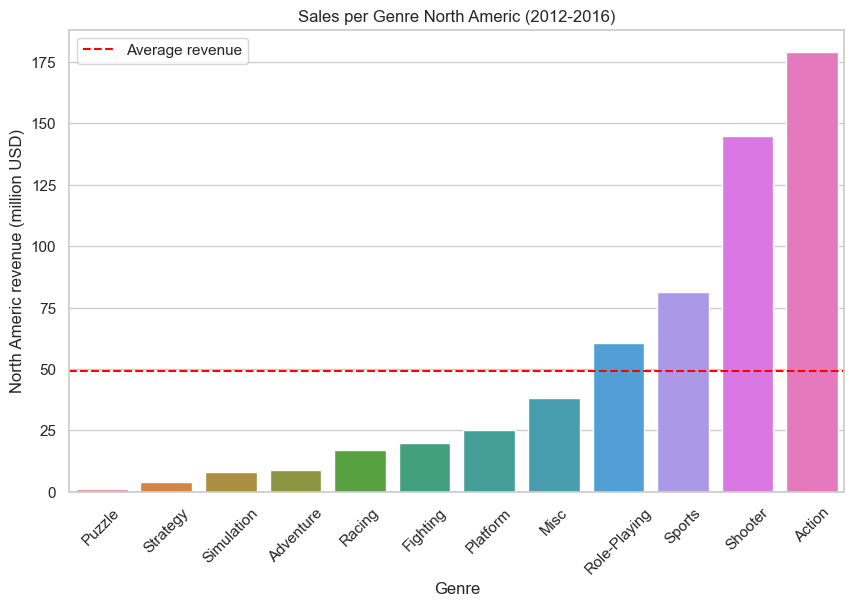

In [82]:
# criação gráfico de barras para visualização resultados agregado
sns.barplot(
    data=sales_per_genre_na, 
    x='genre', 
    y='na_sales', 
    hue='genre'
    )
plt.title('Sales per Genre North Americ (2012-2016)')
plt.ylabel('North Americ revenue (million USD)')
plt.xlabel('Genre')
plt.axhline(
    y=sales_per_genre_na['na_sales'].mean(), 
    linestyle='--', 
    color='red',
    label='Average revenue')
plt.legend()
plt.xticks(rotation=45)
plt.show()

Os gêneros com maior receita na América do Norte são Action, Shooter, Sports e Role-Playing.

#### Japan

##### Platform

In [56]:
# agregado vendas por plataforma em JP
sales_per_platforms_jp = games_active.groupby('platform')['jp_sales'].sum().reset_index().sort_values('jp_sales', ascending=True)

In [71]:
# agregado vendas brutas por plataforma em JP ao longo dos últimos anos
platforms_performance_jp = games_active.groupby(['platform', 'year_of_release'])['jp_sales'].sum().reset_index()

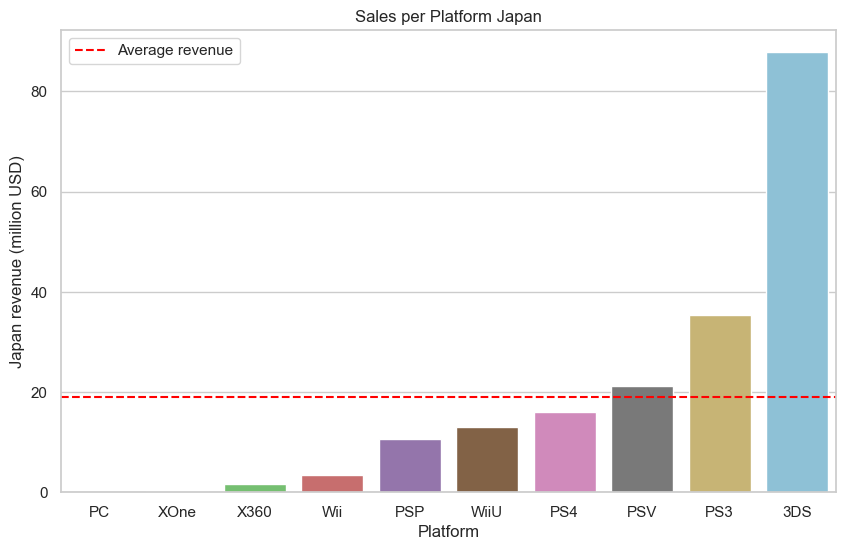

In [ ]:
# criação gráfico de barras para visualização resultados agregado
sns.barplot(
    data=sales_per_platforms_jp, 
    x='platform', 
    y='jp_sales', 
    hue='platform'
    )
plt.title('Sales per Platform Japan (2012-2016)')
plt.ylabel('Japan revenue (million USD)')
plt.xlabel('Platform')
plt.axhline(
    y=sales_per_platforms_jp['jp_sales'].mean(),
    linestyle='--',
    color='red',
    label='Average revenue'
    )
plt.legend()
plt.show()

Em números brutos, as plataformas com maior receita no Japão são 3DS, PS3 e PSV.

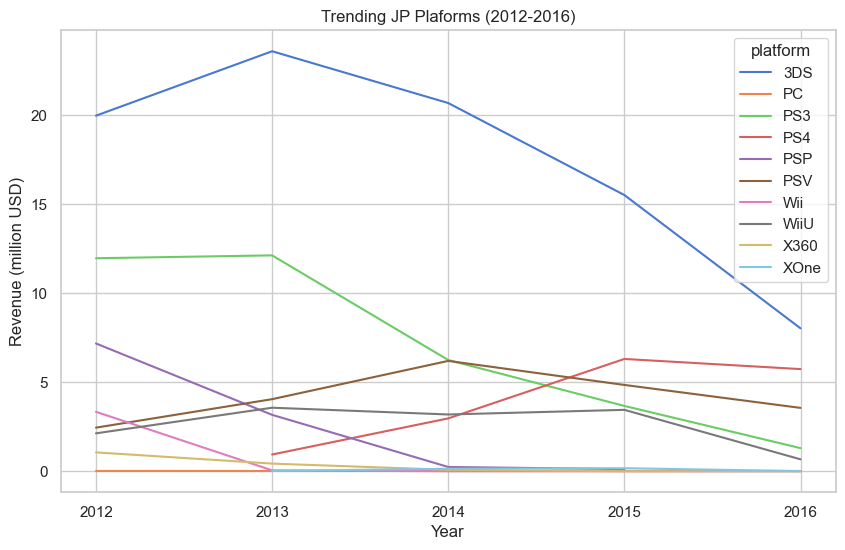

In [ ]:
# visualização tendência de vendas em plataformas últimos 5 anos
sns.lineplot(
    data=platforms_performance_jp,
    x='year_of_release',
    y='jp_sales',
    hue='platform'
)
plt.title('Trending Japan Plaforms (2012-2016)')
plt.ylabel('Revenue (million USD)')
plt.xlabel('Year')
plt.xticks(platforms_performance_jp['year_of_release'].unique())
plt.show()

A plataforma 3DS, líder de receita, apresenta queda nos últimos anos em Japão. Enquanto a PS4 apresenta tendência de crescimento, e WiiU tendência de estabilização. 

##### Genre

In [58]:
# agregado vendas por genêro em JP
sales_per_genre_jp = games_active.groupby('genre')['jp_sales'].sum().reset_index().sort_values('jp_sales', ascending=True)

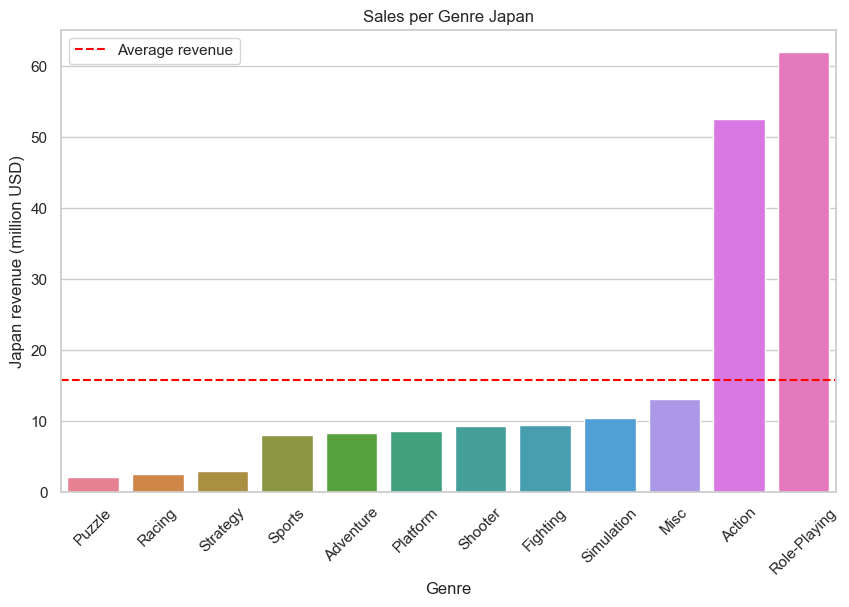

In [ ]:
# criação gráfico de barras para visualização resultados agregado
sns.barplot(
    data=sales_per_genre_jp, 
    x='genre', 
    y='jp_sales', 
    hue='genre'
    )
plt.title('Sales per Genre Japan (2012-2016)')
plt.ylabel('Japan revenue (million USD)')
plt.xlabel('Genre')
plt.axhline(
    y=sales_per_genre_jp['jp_sales'].mean(), 
    linestyle='--', 
    color='red',
    label='Average revenue')
plt.legend()
plt.xticks(rotation=45)
plt.show()

Os gêneros com maior receita no Japão são Role-Playing e Action — padrão distinto do observado em NA, onde Shooter e Sports figuram no topo.

#### Europe

##### Platform

In [60]:
# agregado vendas por plataforma em EU
sales_per_platforms_eu = games_active.groupby('platform')['eu_sales'].sum().reset_index().sort_values('eu_sales', ascending=True)

In [73]:
# agregado vendas brutas por plataforma em EU ao longo dos últimos anos
platforms_performance_eu = games_active.groupby(['platform', 'year_of_release'])['eu_sales'].sum().reset_index()

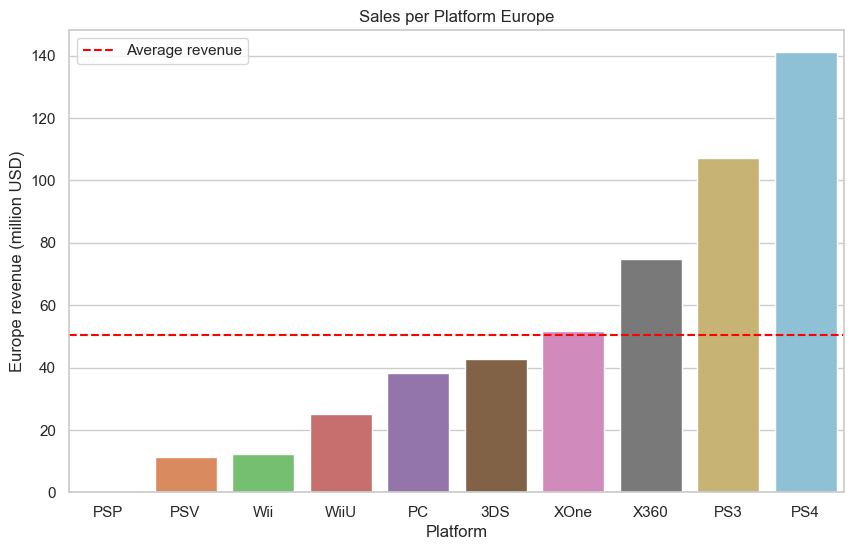

In [ ]:
# criação gráfico de barras para visualização resultados agregado
sns.barplot(
    data=sales_per_platforms_eu, 
    x='platform', 
    y='eu_sales', 
    hue='platform'
    )
plt.title('Sales per Platform Europe (2012-2016)')
plt.ylabel('Europe revenue (million USD)')
plt.xlabel('Platform')
plt.axhline(
    y=sales_per_platforms_eu['eu_sales'].mean(),
    linestyle='--',
    color='red',
    label='Average revenue'
    )
plt.legend()
plt.show()

Em números brutos, as plataformas com maior receita na Europa são PS4, PS3 e X360.

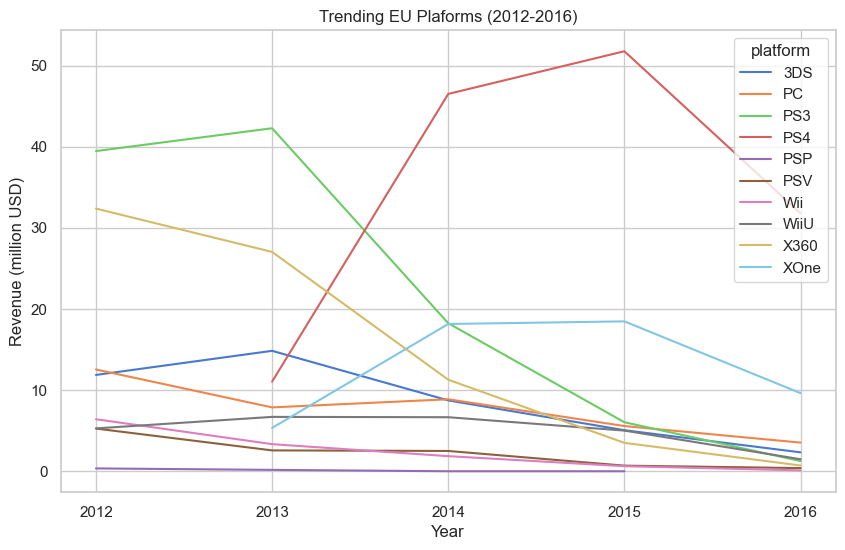

In [74]:
# visualização tendência de vendas em plataformas últimos 5 anos
sns.lineplot(
    data=platforms_performance_eu,
    x='year_of_release',
    y='eu_sales',
    hue='platform'
)
plt.title('Trending EU Plaforms (2012-2016)')
plt.ylabel('Revenue (million USD)')
plt.xlabel('Year')
plt.xticks(platforms_performance_eu['year_of_release'].unique())
plt.show()

Europa apresenta perfil semelhante ao padrão Norte Americano: tendência de crescimento nas plataformas mais recentes: PS4 e XOne.

##### Genre

In [62]:
# agregado vendas por genêro em EU
sales_per_genre_eu = games_active.groupby('genre')['eu_sales'].sum().reset_index().sort_values('eu_sales', ascending=True)

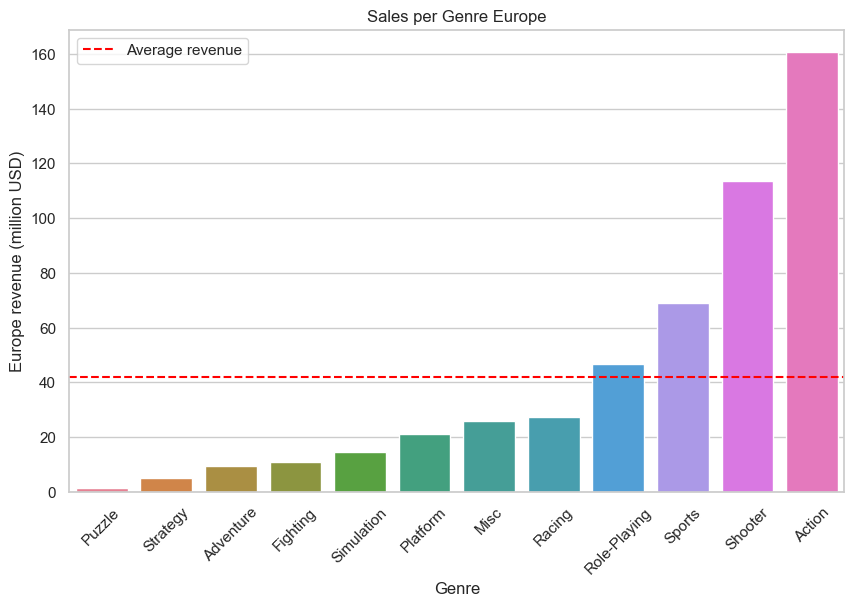

In [ ]:
# criação gráfico de barras para visualização resultados agregado
sns.barplot(
    data=sales_per_genre_eu, 
    x='genre', 
    y='eu_sales', 
    hue='genre'
    )
plt.title('Sales per Genre Europe (2012-2016)')
plt.ylabel('Europe revenue (million USD)')
plt.xlabel('Genre')
plt.axhline(
    y=sales_per_genre_eu['eu_sales'].mean(), 
    linestyle='--', 
    color='red',
    label='Average revenue')
plt.legend()
plt.xticks(rotation=45)
plt.show()

Os gêneros com maior receita na Europa são Action, Shooter, Sports e Role-Playing — padrão convergente com o observado em NA.

#### Others regions

##### Platform

In [64]:
# agregado vendas por plataforma em Other
sales_per_platforms_other = games_active.groupby('platform')['other_sales'].sum().reset_index().sort_values('other_sales', ascending=True)

In [76]:
# agregado vendas brutas por plataforma em Other Regions ao longo dos últimos anos
platforms_performance_other = games_active.groupby(['platform', 'year_of_release'])['other_sales'].sum().reset_index()

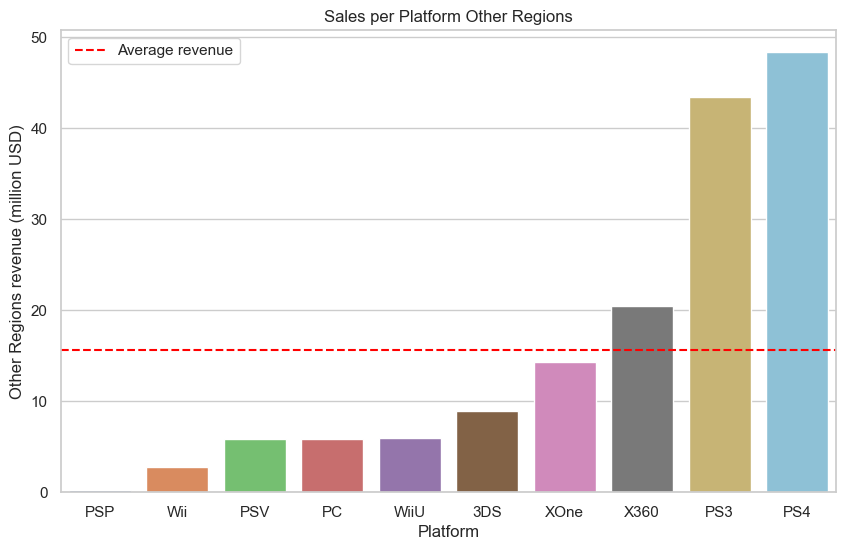

In [ ]:
# criação gráfico de barras para visualização resultados agregado
sns.barplot(
    data=sales_per_platforms_other, 
    x='platform', 
    y='other_sales', 
    hue='platform'
    )
plt.title('Sales per Platform Other Regions (2012-2016)')
plt.ylabel('Other Regions revenue (million USD)')
plt.xlabel('Platform')
plt.axhline(
    y=sales_per_platforms_other['other_sales'].mean(),
    linestyle='--',
    color='red',
    label='Average revenue'
    )
plt.legend()
plt.show()

Em números brutos, as plataformas com maior receita nas demais regiões são PS4, PS3 e X360.

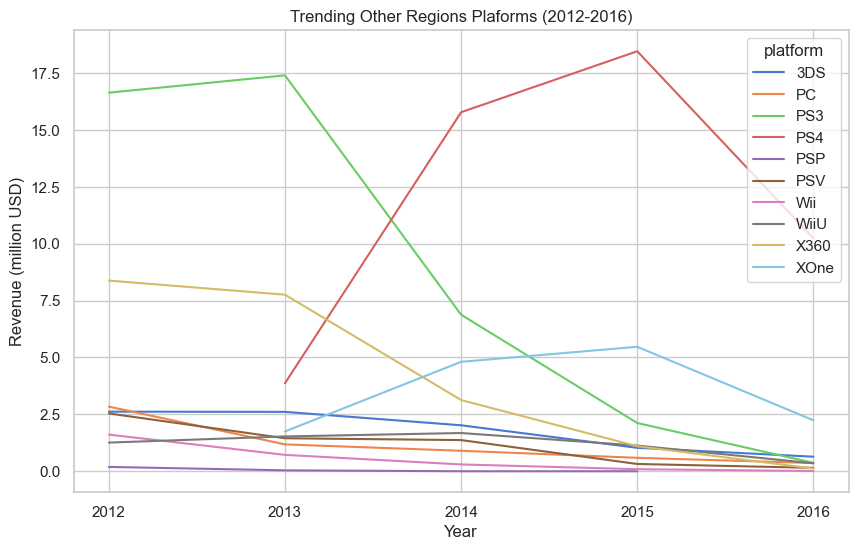

In [ ]:
# visualização tendência de vendas em plataformas últimos 5 anos
sns.lineplot(
    data=platforms_performance_other,
    x='year_of_release',
    y='other_sales',
    hue='platform'
)
plt.title('Trending Plaforms Other Regions (2012-2016)')
plt.ylabel('Revenue (million USD)')
plt.xlabel('Year')
plt.xticks(platforms_performance_eu['year_of_release'].unique())
plt.show()

Regiões alternativas apresenta perfil semelhante ao padrão Europeu e Norte Americano: tendência de crescimento nas plataformas mais recentes: PS4 e XOne.

##### Genre

In [66]:
# agregado vendas por genêro em EU
sales_per_genre_other = games_active.groupby('genre')['other_sales'].sum().reset_index().sort_values('other_sales', ascending=True)

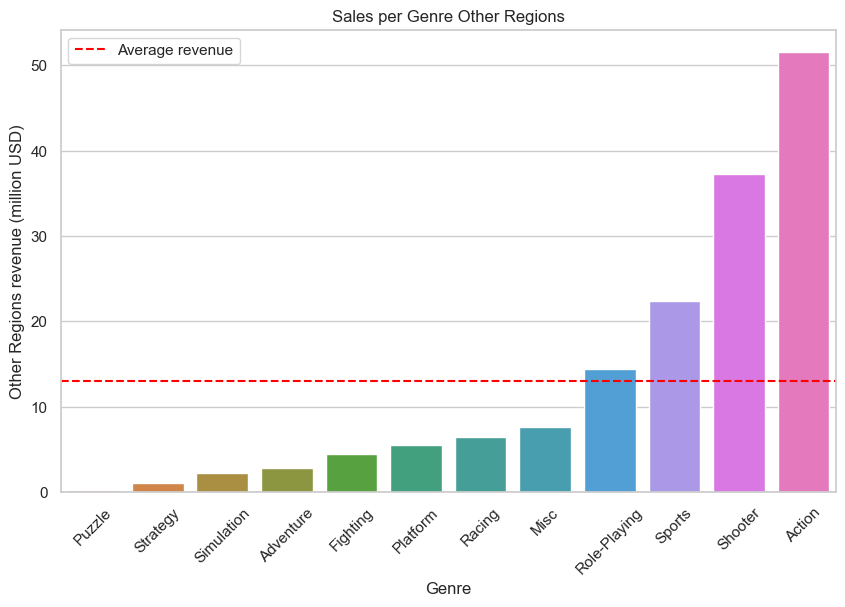

In [ ]:
# criação gráfico de barras para visualização resultados agregado
sns.barplot(
    data=sales_per_genre_other, 
    x='genre', 
    y='other_sales', 
    hue='genre'
    )
plt.title('Sales per Genre Other Regions (2012-2016)')
plt.ylabel('Other Regions revenue (million USD)')
plt.xlabel('Genre')
plt.axhline(
    y=sales_per_genre_other['other_sales'].mean(), 
    linestyle='--', 
    color='red',
    label='Average revenue')
plt.legend()
plt.xticks(rotation=45)
plt.show()

Os gêneros com maior receita nas demais regiões são Action, Shooter e Sports e Role-Playing — padrão alinhado com NA e EU.

### Testes Estatísticos